<a href="https://colab.research.google.com/github/jerrinojacob/Data-Science-Portfolio/blob/main/project_01_transaction_success_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Problem Definition**

This project address a binary classification problem attempting to predict the customer behavior with the dataset that is provided. The objective is to predict if the future customers will make certain decisions based on the historical data provided. This project is a supervised and expects a categorical outcome using the Gaussian Naive Bayes modeling.

**##Data Collection/Sources**

### Importing Libraries for
*   Data Loading
*   Data Cleaning/Manipulation
*   Data Computation
*   Data Visualization
*   SciKit Learning for Modeling



In [61]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

import seaborn as sns

from IPython.display import Image
from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

### **Extracting Data for Analysis**
*   Loading data from AWS url "[Transaction.train.big.csv](https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv)"
*   Reading the csv file into a dataframe
*   Studying the data, metadata to understand the story behind the data and identifying the significant issues and planning on how to eliminate them.



In [62]:
# Initializing the url to a variable
url='https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv'

# Extracting the content of the csv file into a dataframe
txn_train_df = pd.read_csv(url)

In [63]:
print(f"Data Details - Training Dataset:\n------------------------------------------------\nDimensions(/Shape): \t{txn_train_df.shape[0]:,} x {txn_train_df.shape[1]:,}\n")
print(f"Total Elements(/Size): \t{txn_train_df.size:,}\n\nSample Dataset:\n------------------------------------------------\nTop Five Events\n-----------------")
txn_train_df.head()

Data Details - Training Dataset:
------------------------------------------------
Dimensions(/Shape): 	1,050,000 x 104

Total Elements(/Size): 	109,200,000

Sample Dataset:
------------------------------------------------
Top Five Events
-----------------


,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
print(f"Bottom Five Events\n-----------------")
txn_train_df.tail()

Bottom Five Events
-----------------


,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049999,1049999,train_1049999,0.0,2.1828,12.3805,17.5654,NaN,8.1795,NaN,NaN,...,NaN,-12.1108,NaN,10.7608,NaN,NaN,NaN,NaN,NaN,14.1690


In [65]:
print(f"-------------Generating detail information of the dataframe-------------")
txn_train_df.info(verbose=True)

-------------Generating detail information of the dataframe-------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Data columns (total 104 columns):
 #    Column      Dtype  
---   ------      -----  
 0    Unnamed: 0  int64  
 1    ID_code     object 
 2    target      float64
 3    var_0       float64
 4    var_1       float64
 5    var_2       float64
 6    var_3       float64
 7    var_4       float64
 8    var_5       float64
 9    var_6       float64
 10   var_7       float64
 11   var_8       float64
 12   var_9       float64
 13   var_10      float64
 14   var_11      float64
 15   var_12      float64
 16   var_13      float64
 17   var_14      float64
 18   var_15      float64
 19   var_16      float64
 20   var_17      float64
 21   var_18      float64
 22   var_19      float64
 23   var_20      float64
 24   var_21      float64
 25   var_22      float64
 26   var_23      float64
 27   var_24      float64
 28   var_25      float64
 29   v

In [66]:
numeric_int = len(txn_train_df.select_dtypes(include=['int64']).columns)
numeric_float = len(txn_train_df.select_dtypes(include=['float64']).columns)
categorical_dtype = len(txn_train_df.select_dtypes(include=['object']).columns)
print(f'Out of the {txn_train_df.shape[1]} features/columns, the following are the data types listed:\n- integer: {numeric_int},\n- float: {numeric_float}, and\n- object: {categorical_dtype}')

Out of the 104 features/columns, the following are the data types listed:
- integer: 1,
- float: 102, and
- object: 1


###Based on the above observation:
* There are 1,050,000 instances and 104 features of which:
  - Numerical: 103
    - integer: 1
    - float:   102
  - Object :   1

### Now determining the Descriptive Statistics for each Numerical Features

In [67]:
#pd.set_option('display.max_rows', None) # Show all the elements in describe
#pd.set_option('display.max_rows') # To return to default
txn_train_df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1050000.0,NaN,NaN,NaN,524999.5,303109.035663,0.0,262499.75,524999.5,787499.25,1049999.0
ID_code,1050000,1050000,train_1049983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,180000.0,NaN,NaN,NaN,0.100222,0.300297,0.0,0.0,0.0,0.0,1.0
var_0,180000.0,NaN,NaN,NaN,7.440715,3.021636,-2.6917,5.160325,7.35095,9.511125,16.7165
var_1,180000.0,NaN,NaN,NaN,15.870166,3.010492,6.2993,13.8304,15.9346,18.061425,26.0791
...,...,...,...,...,...,...,...,...,...,...,...
var_96,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_97,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_98,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_99,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
#Checking for uniqueness of the dataset
txn_train_df.nunique().sort_values(ascending=False)

,0
Unnamed: 0,1050000
ID_code,1050000
var_52,137280
var_86,134537
var_94,131746
...,...
var_93,0
var_96,0
var_97,0
var_98,0


In [69]:
# 1. identifying the target column for this problem
# identifying if there are binary values in any of the features.
target_col = [i for i in txn_train_df.columns if txn_train_df[i].nunique() == 2]
print(f"List of Target from the given dataset: {target_col}\n---------------------------------------------------\n\n")
print(f"Value counts of {target_col}")
txn_train_df['target'].value_counts(dropna=False)

List of Target from the given dataset: ['target']
---------------------------------------------------


Value counts of ['target']


,count
target,
NaN,870000
0.0,161960
1.0,18040


In [70]:
# 2. identifying the categorical columns that may need to be dropped

drop_categorical_obj_list = txn_train_df.columns[txn_train_df.nunique() == len(txn_train_df)].to_list()
print(f"Categorical Objects:\n - \"{drop_categorical_obj_list[0]}\" : \t{txn_train_df['ID_code'].nunique():,} unique data and \n - \"{drop_categorical_obj_list[1]}\" :\t\t{txn_train_df['Unnamed: 0'].nunique():,} unique data")

Categorical Objects:
 - "Unnamed: 0" : 	1,050,000 unique data and 
 - "ID_code" :		1,050,000 unique data


In [71]:
# 3. Determining frequency of features having null values
# 3.1 Checking the % of null values in each feature
(txn_train_df.isna().sum() / len(txn_train_df) * 100).sort_values().apply(lambda x: f'{x:.2f}%')

#( (1 - (txn_train_df.isna().sum() / len(txn_train_df))) * 100).sort_values(ascending=False).apply(lambda x: f'{x:.2f}%')
#(( (1 - (txn_train_df.isna().sum() / len(txn_train_df))) * 100)==0).sort_values()
#((txn_train_df.isna().sum() / len(txn_train_df) * 100)==100).sort_values()

,0
Unnamed: 0,0.00%
ID_code,0.00%
target,82.86%
var_0,82.86%
var_1,82.86%
...,...
var_93,100.00%
var_96,100.00%
var_97,100.00%
var_98,100.00%


In [72]:
# 3.2 Creating a list of null Features
print(f"Total count of Features that are null from the training dataset: {txn_train_df.isna().all().sum()}\n\nThe List of Features that need to be dropped:\n---------------------------------------------------------------")
drop_feature_list=txn_train_df.columns[txn_train_df.nunique() == 0]
drop_feature_list

Total count of Features that are null from the training dataset: 51

The List of Features that need to be dropped:
---------------------------------------------------------------


Index(['var_3', 'var_5', 'var_6', 'var_9', 'var_10', 'var_11', 'var_12',
       'var_13', 'var_16', 'var_18', 'var_19', 'var_23', 'var_25', 'var_30',
       'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_40', 'var_42',
       'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_50', 'var_51',
       'var_53', 'var_54', 'var_55', 'var_58', 'var_59', 'var_60', 'var_64',
       'var_68', 'var_69', 'var_71', 'var_74', 'var_76', 'var_77', 'var_79',
       'var_81', 'var_90', 'var_91', 'var_93', 'var_95', 'var_96', 'var_97',
       'var_98', 'var_99'],
      dtype='object')

In [73]:
#Very expensive using nunique
#c=txn_train_df[txn_train_df.columns[txn_train_df.nunique() != 0]]

###Based on the observation and anlysis of the dataset, the following are facts:
*  The target for this problem is identified as ***'target'***. This target contains large number of rows that have nulls which needs to be dropped as they pose no value into the model and would distort the analysis and prediction.
*   The catagorical columns:
    - 'Unnamed: 0', and
    - 'ID_code'
*   They are having unique identifiers with no duplicate values. They are not binary and hence not categorical to be used for the model. This must be dropped for the modeling.
*  The features available have large number of nulls ~83% and 51 features with 100% nulls. Those with 100% nulls will be dropped as they pose no meaning to the model and those that are ~83% must be cleaned and then imputed with a mean.

###I have listed features that are 100% null in a list and the non categorical columns also in a list to drop for further analysis of the model.

In [74]:
# Backup#1
txn_train_bkp1=txn_train_df.copy()

In [75]:
# Extracting a list of rows indices with'target'==null
target_null_list = txn_train_df[txn_train_df['target'].isnull()].index.tolist()
target_null_list

[0,
 1,
 2,
 4,
 6,
 7,
 8,
 9,
 10,
 12,
 13,
 14,
 16,
 17,
 18,
 20,
 21,
 23,
 24,
 25,
 26,
 27,
 28,
 30,
 31,
 32,
 34,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 48,
 49,
 50,
 51,
 52,
 54,
 56,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 68,
 69,
 70,
 73,
 74,
 75,
 76,
 78,
 79,
 80,
 81,
 82,
 83,
 86,
 87,
 88,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 99,
 102,
 103,
 104,
 105,
 106,
 108,
 109,
 110,
 111,
 112,
 114,
 115,
 117,
 119,
 122,
 123,
 124,
 126,
 127,
 129,
 130,
 131,
 133,
 134,
 135,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 145,
 146,
 147,
 148,
 149,
 152,
 153,
 154,
 157,
 158,
 159,
 160,
 162,
 164,
 166,
 167,
 168,
 170,
 171,
 172,
 173,
 174,
 176,
 178,
 179,
 180,
 182,
 184,
 185,
 186,
 187,
 190,
 191,
 192,
 193,
 194,
 195,
 196,
 197,
 200,
 201,
 202,
 203,
 206,
 207,
 208,
 209,
 210,
 211,
 212,
 213,
 214,
 215,
 216,
 218,
 219,
 220,
 222,
 223,
 224,
 225,
 227,
 228,
 229,
 230,
 231,
 232,
 233,
 234,
 237,
 238,
 239,

##**Data Cleaning**

* In this process, I will be trying to clean the dataset to be ready for the model.
I will remove the nulls events from the target, features that have only null values, remove the highly unique value columns, immpute if any of the features have null values as part of the cleaning process.

###Removing null values from target

In [76]:
# Creating a new dataset with 'target' having no null values.
txn_train_target = txn_train_df.drop(target_null_list)
#txn_train_df.shape
#txn_train_target.shape

In [77]:
# Backup#2: 'target' with no null events
txn_train_bkp2 = txn_train_target
txn_train_bkp2.head()
txn_train_bkp2.tail()

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
1049990,1049990,train_1049990,0.0,7.9632,20.4650,10.7295,NaN,2.9322,NaN,NaN,...,NaN,10.4219,NaN,-19.7158,NaN,NaN,NaN,NaN,NaN,14.0582
1049993,1049993,train_1049993,0.0,5.0862,14.4785,17.3709,NaN,-2.4732,NaN,NaN,...,NaN,-2.8052,NaN,-13.7290,NaN,NaN,NaN,NaN,NaN,14.3794
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049999,1049999,train_1049999,0.0,2.1828,12.3805,17.5654,NaN,8.1795,NaN,NaN,...,NaN,-12.1108,NaN,10.7608,NaN,NaN,NaN,NaN,NaN,14.1690


In [78]:
txn_train_target.info(verbose=True)


<class 'pandas.core.frame.DataFrame'>
Index: 180000 entries, 3 to 1049999
Data columns (total 104 columns):
 #    Column      Dtype  
---   ------      -----  
 0    Unnamed: 0  int64  
 1    ID_code     object 
 2    target      float64
 3    var_0       float64
 4    var_1       float64
 5    var_2       float64
 6    var_3       float64
 7    var_4       float64
 8    var_5       float64
 9    var_6       float64
 10   var_7       float64
 11   var_8       float64
 12   var_9       float64
 13   var_10      float64
 14   var_11      float64
 15   var_12      float64
 16   var_13      float64
 17   var_14      float64
 18   var_15      float64
 19   var_16      float64
 20   var_17      float64
 21   var_18      float64
 22   var_19      float64
 23   var_20      float64
 24   var_21      float64
 25   var_22      float64
 26   var_23      float64
 27   var_24      float64
 28   var_25      float64
 29   var_26      float64
 30   var_27      float64
 31   var_28      float64
 32   va

###Removing the non categorical columns

In [79]:
#Backup#3: Removing the non categorical columns
txn_train_bkp3 = txn_train_target.copy()
#Restore Backup if needed
txn_train_target = txn_train_bkp3.copy()

In [80]:
# Checking again if the columns referenced are correct.
drop_categorical_obj_list

['Unnamed: 0', 'ID_code']

In [81]:
#Verifying the dataset to drop
txn_train_target.head()

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
5,5,train_5,0.0,14.6962,18.3383,17.4788,NaN,-9.1355,NaN,NaN,...,NaN,-2.0111,NaN,-3.6166,NaN,NaN,NaN,NaN,NaN,14.4520
11,11,train_11,0.0,4.4949,14.4142,13.2219,NaN,4.9140,NaN,NaN,...,NaN,13.9424,NaN,-15.5776,NaN,NaN,NaN,NaN,NaN,14.1222
15,15,train_15,0.0,4.9657,16.2867,17.9579,NaN,0.6017,NaN,NaN,...,NaN,3.7943,NaN,5.6184,NaN,NaN,NaN,NaN,NaN,14.0619
19,19,train_19,0.0,9.4287,18.7822,10.7630,NaN,-0.7532,NaN,NaN,...,NaN,-5.6677,NaN,-1.8961,NaN,NaN,NaN,NaN,NaN,14.0275


In [82]:
# dropping the columns
txn_train_target.drop(columns=drop_categorical_obj_list, inplace=True, axis=1)
txn_train_target

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,-1.9254,6.4760,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
5,0.0,14.6962,18.3383,17.4788,NaN,-9.1355,NaN,NaN,-6.4882,6.0821,...,NaN,-2.0111,NaN,-3.6166,NaN,NaN,NaN,NaN,NaN,14.4520
11,0.0,4.4949,14.4142,13.2219,NaN,4.9140,NaN,NaN,4.0501,5.8144,...,NaN,13.9424,NaN,-15.5776,NaN,NaN,NaN,NaN,NaN,14.1222
15,0.0,4.9657,16.2867,17.9579,NaN,0.6017,NaN,NaN,-5.4904,6.6670,...,NaN,3.7943,NaN,5.6184,NaN,NaN,NaN,NaN,NaN,14.0619
19,0.0,9.4287,18.7822,10.7630,NaN,-0.7532,NaN,NaN,8.8477,6.8045,...,NaN,-5.6677,NaN,-1.8961,NaN,NaN,NaN,NaN,NaN,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,0.0,7.9632,20.4650,10.7295,NaN,2.9322,NaN,NaN,5.0267,7.1953,...,NaN,10.4219,NaN,-19.7158,NaN,NaN,NaN,NaN,NaN,14.0582
1049993,0.0,5.0862,14.4785,17.3709,NaN,-2.4732,NaN,NaN,-2.5987,6.6798,...,NaN,-2.8052,NaN,-13.7290,NaN,NaN,NaN,NaN,NaN,14.3794
1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,-6.8112,7.3226,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,1.6614,6.1486,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689


In [83]:
# Checking if the columns dropped
txn_train_target.head()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,-1.9254,6.4760,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
5,0.0,14.6962,18.3383,17.4788,NaN,-9.1355,NaN,NaN,-6.4882,6.0821,...,NaN,-2.0111,NaN,-3.6166,NaN,NaN,NaN,NaN,NaN,14.4520
11,0.0,4.4949,14.4142,13.2219,NaN,4.9140,NaN,NaN,4.0501,5.8144,...,NaN,13.9424,NaN,-15.5776,NaN,NaN,NaN,NaN,NaN,14.1222
15,0.0,4.9657,16.2867,17.9579,NaN,0.6017,NaN,NaN,-5.4904,6.6670,...,NaN,3.7943,NaN,5.6184,NaN,NaN,NaN,NaN,NaN,14.0619
19,0.0,9.4287,18.7822,10.7630,NaN,-0.7532,NaN,NaN,8.8477,6.8045,...,NaN,-5.6677,NaN,-1.8961,NaN,NaN,NaN,NaN,NaN,14.0275


###Removing the feature columns with null

In [84]:
#Backup#4: Removing the feature columns with null values
txn_train_bkp4 = txn_train_target.copy()
#Restore Backup if needed
txn_train_target = txn_train_bkp4.copy()

In [85]:
#Verifying the dataset to drop
txn_train_target.head()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,-1.9254,6.4760,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
5,0.0,14.6962,18.3383,17.4788,NaN,-9.1355,NaN,NaN,-6.4882,6.0821,...,NaN,-2.0111,NaN,-3.6166,NaN,NaN,NaN,NaN,NaN,14.4520
11,0.0,4.4949,14.4142,13.2219,NaN,4.9140,NaN,NaN,4.0501,5.8144,...,NaN,13.9424,NaN,-15.5776,NaN,NaN,NaN,NaN,NaN,14.1222
15,0.0,4.9657,16.2867,17.9579,NaN,0.6017,NaN,NaN,-5.4904,6.6670,...,NaN,3.7943,NaN,5.6184,NaN,NaN,NaN,NaN,NaN,14.0619
19,0.0,9.4287,18.7822,10.7630,NaN,-0.7532,NaN,NaN,8.8477,6.8045,...,NaN,-5.6677,NaN,-1.8961,NaN,NaN,NaN,NaN,NaN,14.0275


In [86]:
# Checking again if the columns referenced are correct.
drop_feature_list

Index(['var_3', 'var_5', 'var_6', 'var_9', 'var_10', 'var_11', 'var_12',
       'var_13', 'var_16', 'var_18', 'var_19', 'var_23', 'var_25', 'var_30',
       'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_40', 'var_42',
       'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_50', 'var_51',
       'var_53', 'var_54', 'var_55', 'var_58', 'var_59', 'var_60', 'var_64',
       'var_68', 'var_69', 'var_71', 'var_74', 'var_76', 'var_77', 'var_79',
       'var_81', 'var_90', 'var_91', 'var_93', 'var_95', 'var_96', 'var_97',
       'var_98', 'var_99'],
      dtype='object')

In [87]:
# dropping the columns
txn_train_target.drop(columns=drop_feature_list, inplace=True, axis=1)
txn_train_target

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


###Cross verifying if the dataset is ready and identifying if the dataset requires any imputation

In [88]:
#Checking the detailed information of the dataset
txn_train_target.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180000 entries, 3 to 1049999
Data columns (total 51 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   target   180000 non-null  float64
 1   var_0    180000 non-null  float64
 2   var_1    180000 non-null  float64
 3   var_2    180000 non-null  float64
 4   var_4    180000 non-null  float64
 5   var_7    180000 non-null  float64
 6   var_8    180000 non-null  float64
 7   var_14   180000 non-null  float64
 8   var_15   180000 non-null  float64
 9   var_17   180000 non-null  float64
 10  var_20   180000 non-null  float64
 11  var_21   180000 non-null  float64
 12  var_22   180000 non-null  float64
 13  var_24   180000 non-null  float64
 14  var_26   180000 non-null  float64
 15  var_27   180000 non-null  float64
 16  var_28   180000 non-null  float64
 17  var_29   180000 non-null  float64
 18  var_36   180000 non-null  float64
 19  var_37   180000 non-null  float64
 20  var_38   180000 non-null  floa

In [89]:
#Checking for the uniqueness of the dataset after transformation
txn_train_target.nunique().sort_values(ascending=True)

,0
target,2
var_100,8479
var_56,9500
var_84,10512
var_15,17760
var_61,18053
var_8,19006
var_83,24845
var_63,32995
var_49,37907


In [90]:
print(f"Data Details - Training Dataset:\n------------------------------------------------\nDimensions(/Shape): \t{txn_train_target.shape[0]:,} x {txn_train_target.shape[1]:,}\n")
print(f"Total Elements(/Size): \t{txn_train_target.size:,}\n\nSample Dataset:\n------------------------------------------------\nTop Five Events\n-----------------")
txn_train_target.head()

Data Details - Training Dataset:
------------------------------------------------
Dimensions(/Shape): 	180,000 x 51

Total Elements(/Size): 	9,180,000

Sample Dataset:
------------------------------------------------
Top Five Events
-----------------


,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275


In [91]:
#Checking for any null values to impute values
txn_train_target.isna()

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
15,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1049993,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1049995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1049997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [92]:
#Checking again, since the dataset is large, for any null values to impute values s
if txn_train_target.isnull().any().any():
    print("Still has nulls!")
else:
    print("No nulls found!")

No nulls found!


###Based on the observation
* The required rows and columns have been dropped and cleaned.
* There are no more null values in the reformed dataset.
* No imputation required.

##**Exploratory Data Analysis**

###Independence of the features: Correlation
- Correlation is enforced to understand the relationship between the target and the feature variables.

In [93]:
#Creating the correlation matrix to study the relationship.
txn_train_corr=txn_train_target.corr()
txn_train_corr

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
target,1.000000,0.045506,-0.051718,-0.046433,0.041593,-0.041987,0.052457,0.045281,-0.057373,-0.054375,...,-0.052324,-0.053733,-0.042073,0.047543,-0.063871,-0.042765,0.059306,0.040520,0.049072,-0.047005
var_0,0.045506,1.000000,-0.000892,-0.000225,-0.000269,-0.001320,0.002949,0.002901,-0.007758,-0.002799,...,-0.004960,-0.005451,-0.000716,0.004577,-0.004664,-0.001088,0.000236,0.001668,0.001837,0.001475
var_1,-0.051718,-0.000892,1.000000,0.006064,-0.000821,0.000783,-0.007127,-0.006180,-0.002585,-0.001663,...,0.004265,0.002411,0.001484,-0.003859,-0.000485,0.003141,-0.006188,0.000071,-0.003682,0.003964
var_2,-0.046433,-0.000225,0.006064,1.000000,-0.003427,-0.000108,-0.001809,-0.002786,-0.001177,0.006360,...,0.004890,0.002240,0.001980,-0.001161,0.003921,0.002087,-0.004422,-0.003418,-0.001565,0.002418
var_4,0.041593,-0.000269,-0.000821,-0.003427,1.000000,-0.002750,0.003347,0.001377,-0.004732,-0.001814,...,0.000657,-0.005267,-0.004266,-0.004179,-0.004211,-0.002330,0.000254,0.001090,-0.000468,-0.002807
var_7,-0.041987,-0.001320,0.000783,-0.000108,-0.002750,1.000000,-0.003199,-0.003588,0.002329,0.004282,...,-0.000412,0.003262,0.002574,-0.001824,0.001186,0.002811,0.001306,0.000236,-0.000568,0.004575
var_8,0.052457,0.002949,-0.007127,-0.001809,0.003347,-0.003199,1.000000,0.003472,-0.003858,-0.002727,...,-0.008394,-0.004254,-0.002446,0.001117,-0.003713,-0.003929,0.003837,0.003422,0.003204,0.000821
var_14,0.045281,0.002901,-0.006180,-0.002786,0.001377,-0.003588,0.003472,1.000000,-0.007115,-0.004249,...,-0.002214,-0.002179,-0.003054,-0.000160,-0.000504,-0.004046,0.003136,0.005715,0.001501,-0.000106
var_15,-0.057373,-0.007758,-0.002585,-0.001177,-0.004732,0.002329,-0.003858,-0.007115,1.000000,0.002467,...,0.000581,0.006633,0.004569,-0.001573,0.003251,0.003066,-0.001541,-0.003719,-0.002825,0.004247
var_17,-0.054375,-0.002799,-0.001663,0.006360,-0.001814,0.004282,-0.002727,-0.004249,0.002467,1.000000,...,0.005578,0.001237,0.000210,-0.002714,0.004149,-0.002182,-0.002642,-0.001968,-0.004100,-0.000822


###Heatmap
- Heatmap is used for correlation, to understand the relationship of the feature variables and/or their independence.
- increased the figsize to make it visible but the heatmap still do not give a clarity to the relationship.

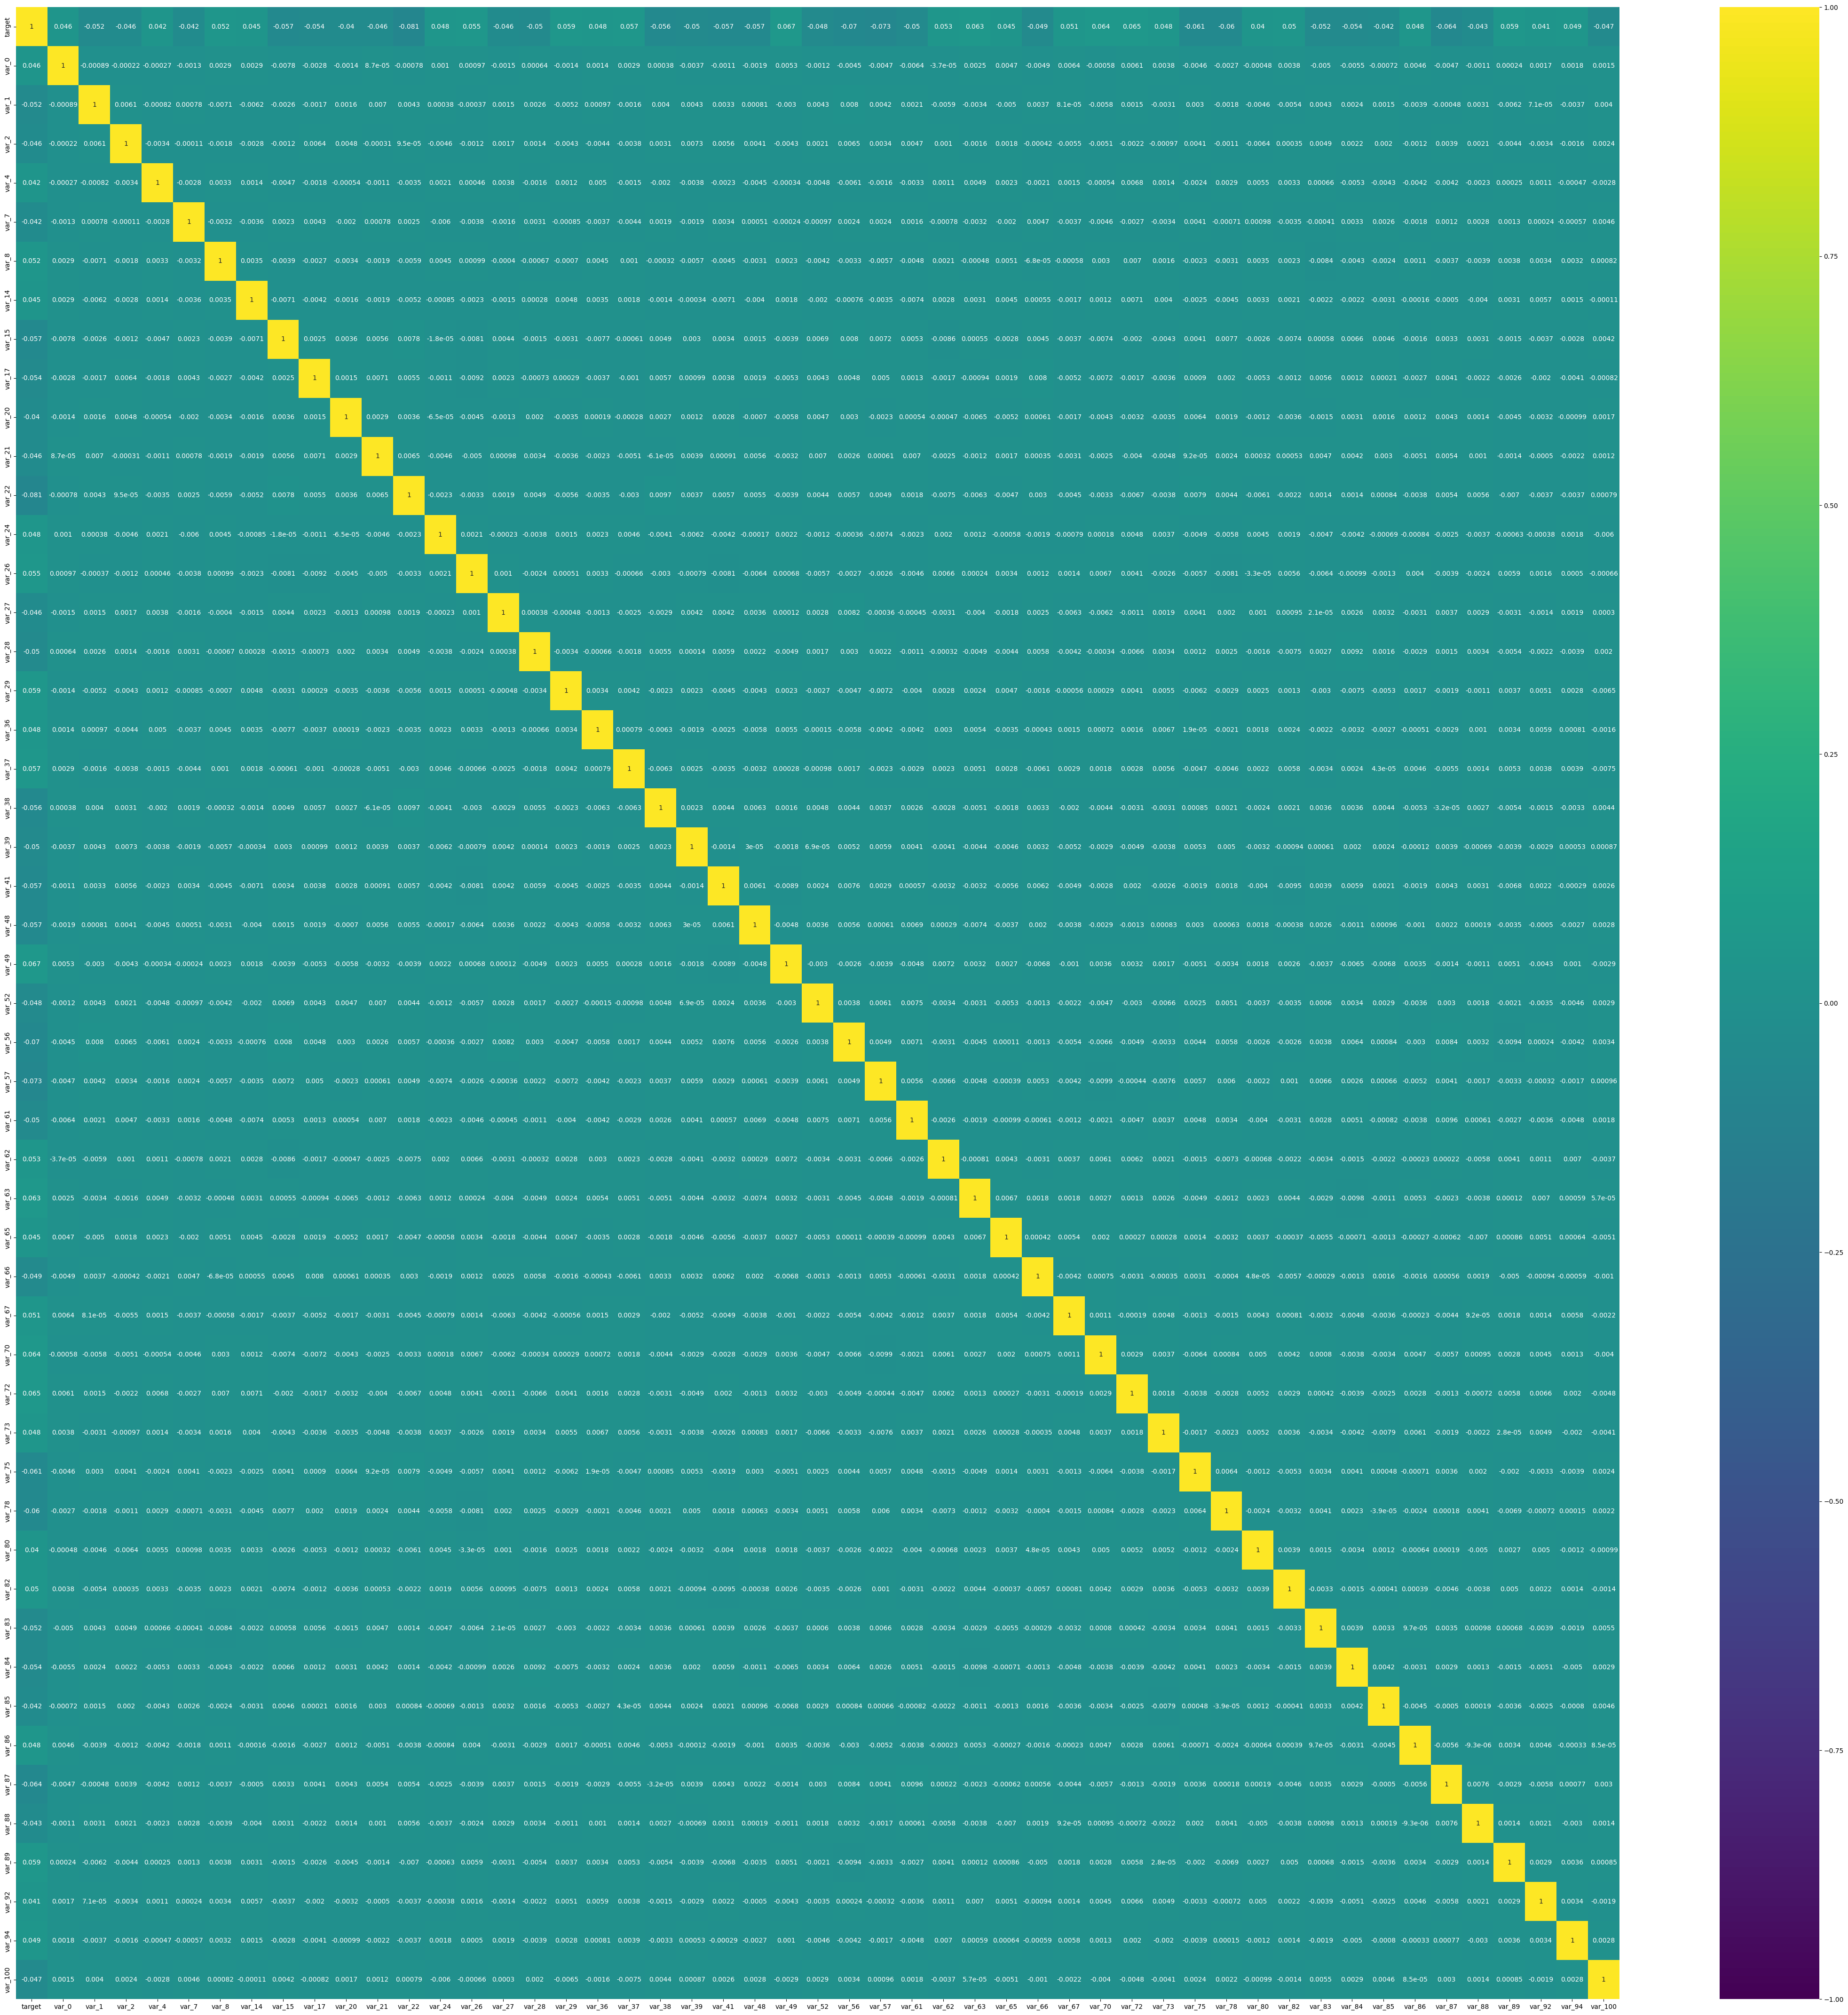

In [94]:
plt.figure(figsize=(55,55))
sns.heatmap(
    txn_train_corr,
    cmap='viridis',
    annot = True,
    vmin = -1,
    vmax = 1
    );

###Histogram
- Histograms helps to check if this dataset meets the criteria of a Normal Distribution for Gaussian Naive Bayes Model.

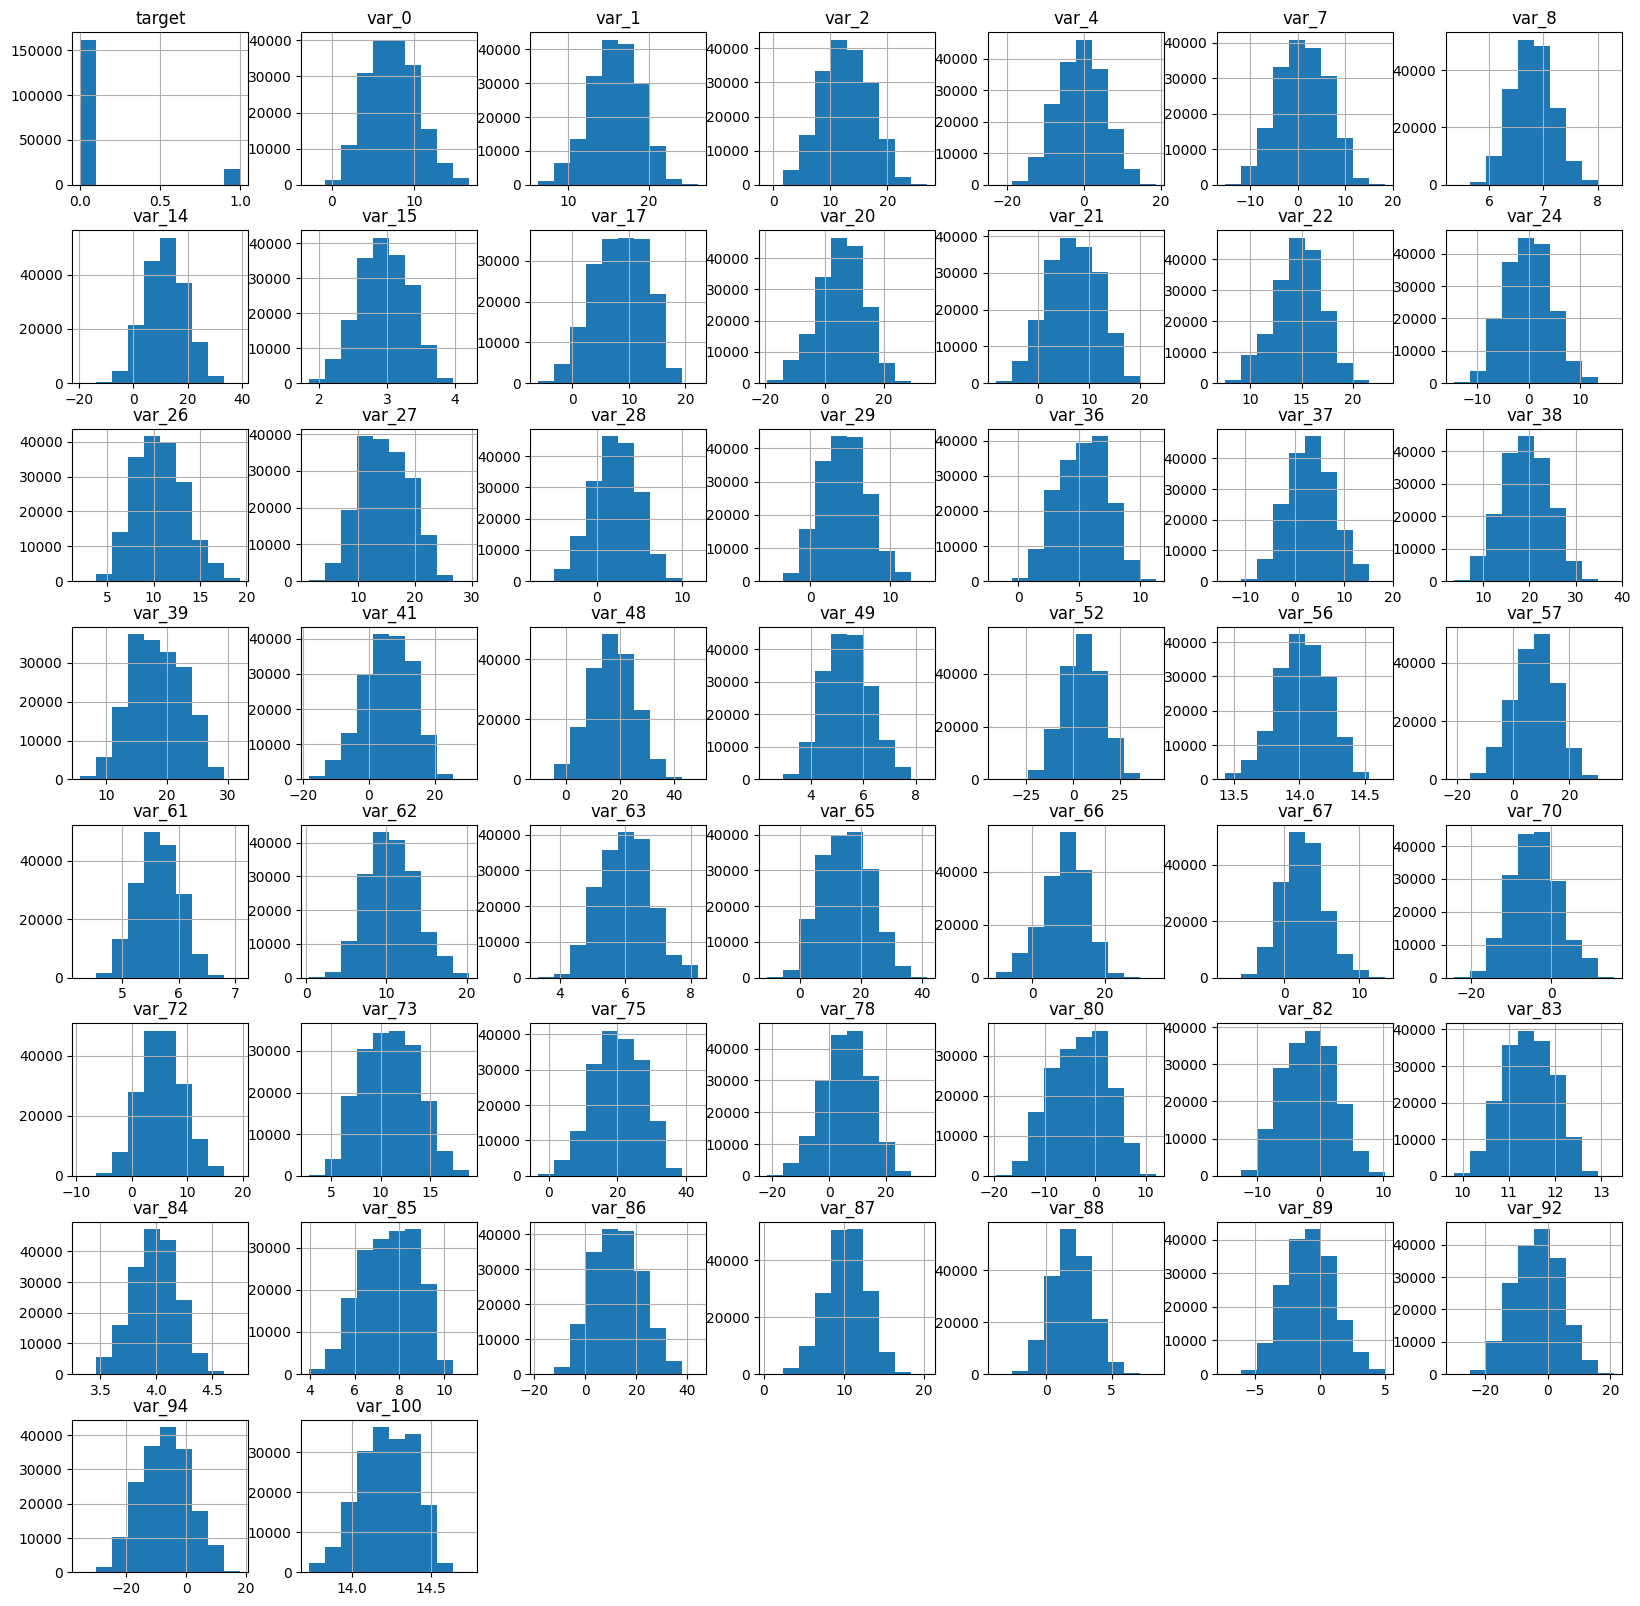

In [95]:
txn_train_target.hist(figsize=(20, 20))
plt.show()

In [96]:
txn_train_target["target"].value_counts() * 100 / txn_train_target["target"].value_counts().sum()

,count
target,
0.0,89.977778
1.0,10.022222


###**Observation**
* Based on the above histograms:
  - Target is imbalanced;
    - ~90% samples at 0 and
    - ~10% samples at 1
  - Feature variables are skewed and have multi-peaks
    - some are left skewed like var_4, var_67, var_80, ... etc
    - some are right skewed like var_14, var_15, var_26, ... etc
    - some have multi-peaks like var_27, var_41, var_52, ... etc
    - some are near normal like var_0, var_1, var_2, ... etc

*Outputs show that the data distribution is not normal for most of the variables.


In [97]:
txn_train_predictor = txn_train_target.drop(columns=['target'])
txn_train_predictor.corr()

,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,var_20,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
var_0,1.000000,-0.000892,-0.000225,-0.000269,-0.001320,0.002949,0.002901,-0.007758,-0.002799,-0.001353,...,-0.004960,-0.005451,-0.000716,0.004577,-0.004664,-0.001088,0.000236,0.001668,0.001837,0.001475
var_1,-0.000892,1.000000,0.006064,-0.000821,0.000783,-0.007127,-0.006180,-0.002585,-0.001663,0.001590,...,0.004265,0.002411,0.001484,-0.003859,-0.000485,0.003141,-0.006188,0.000071,-0.003682,0.003964
var_2,-0.000225,0.006064,1.000000,-0.003427,-0.000108,-0.001809,-0.002786,-0.001177,0.006360,0.004796,...,0.004890,0.002240,0.001980,-0.001161,0.003921,0.002087,-0.004422,-0.003418,-0.001565,0.002418
var_4,-0.000269,-0.000821,-0.003427,1.000000,-0.002750,0.003347,0.001377,-0.004732,-0.001814,-0.000539,...,0.000657,-0.005267,-0.004266,-0.004179,-0.004211,-0.002330,0.000254,0.001090,-0.000468,-0.002807
var_7,-0.001320,0.000783,-0.000108,-0.002750,1.000000,-0.003199,-0.003588,0.002329,0.004282,-0.001971,...,-0.000412,0.003262,0.002574,-0.001824,0.001186,0.002811,0.001306,0.000236,-0.000568,0.004575
var_8,0.002949,-0.007127,-0.001809,0.003347,-0.003199,1.000000,0.003472,-0.003858,-0.002727,-0.003417,...,-0.008394,-0.004254,-0.002446,0.001117,-0.003713,-0.003929,0.003837,0.003422,0.003204,0.000821
var_14,0.002901,-0.006180,-0.002786,0.001377,-0.003588,0.003472,1.000000,-0.007115,-0.004249,-0.001595,...,-0.002214,-0.002179,-0.003054,-0.000160,-0.000504,-0.004046,0.003136,0.005715,0.001501,-0.000106
var_15,-0.007758,-0.002585,-0.001177,-0.004732,0.002329,-0.003858,-0.007115,1.000000,0.002467,0.003584,...,0.000581,0.006633,0.004569,-0.001573,0.003251,0.003066,-0.001541,-0.003719,-0.002825,0.004247
var_17,-0.002799,-0.001663,0.006360,-0.001814,0.004282,-0.002727,-0.004249,0.002467,1.000000,0.001476,...,0.005578,0.001237,0.000210,-0.002714,0.004149,-0.002182,-0.002642,-0.001968,-0.004100,-0.000822
var_20,-0.001353,0.001590,0.004796,-0.000539,-0.001971,-0.003417,-0.001595,0.003584,0.001476,1.000000,...,-0.001476,0.003107,0.001610,0.001186,0.004265,0.001449,-0.004506,-0.003241,-0.000988,0.001734


* There is independent relationship will all predictors

###Creating two dataframes with Successful and Unsuccessful transaction

In [98]:
Successful= txn_train_target[txn_train_target['target']==1].copy()
print(f'Successful Target Transaction counts: {Successful['target'].value_counts()}\n\n')
Unsuccessful = txn_train_target[txn_train_target['target']==0].copy()
print(f'Unsuccessful Target Transaction counts: {Unsuccessful['target'].value_counts()}')

Successful Target Transaction counts: target
1.0    18040
Name: count, dtype: int64


Unsuccessful Target Transaction counts: target
0.0    161960
Name: count, dtype: int64


##Processing

In [99]:
#Separating the target and features
X = txn_train_target.drop(columns=['target']).copy()
y = txn_train_target['target'].copy()
print(f'-------------Features dataframe:--------------\n{X}\n\n')
print(f'-------------Target dataframe:-------------\n{y}\n\n')

-------------Features dataframe:--------------
           var_0    var_1    var_2   var_4   var_7   var_8   var_14  var_15  \
3         4.6739  22.3915  15.6015  0.0464 -1.9254  6.4760  21.6435  2.8817   
5        14.6962  18.3383  17.4788 -9.1355 -6.4882  6.0821  11.7476  2.2225   
11        4.4949  14.4142  13.2219  4.9140  4.0501  5.8144  18.7136  3.4990   
15        4.9657  16.2867  17.9579  0.6017 -5.4904  6.6670   8.1019  2.8910   
19        9.4287  18.7822  10.7630 -0.7532  8.8477  6.8045  19.0069  3.2771   
...          ...      ...      ...     ...     ...     ...      ...     ...   
1049990   7.9632  20.4650  10.7295  2.9322  5.0267  7.1953  10.0695  3.0732   
1049993   5.0862  14.4785  17.3709 -2.4732 -2.5987  6.6798   3.0420  2.4057   
1049995  11.3251  16.4148  20.5955 -6.3011 -6.8112  7.3226  14.9182  2.4579   
1049997   8.9941  13.4127   3.9567  3.5744  1.6614  6.1486  12.0996  2.5439   
1049999   2.1828  12.3805  17.5654  8.1795 -5.5755  6.3705   5.1813  2.5118   

    

###Train-Test-Split
* Creating a training and test sets
  1. (X_train,y_train): training set will be used by the GNB model to learn its pattern and relationship between the targets and the features.
  2. (X_test,y_test): test set will be used by the GNB model to compute the performance after comparing the model's predictions with the actual test target

In [100]:
#Creating model with training and test data
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.20, random_state=0)

print(f'-------------Training Features:--------------\n{X_train}\n\n')
print(f'-------------Training Target:-------------\n{y_train}\n\n')
print(f'-------------Test Features:--------------\n{X_test}\n\n')
print(f'-------------Test Target:-------------\n{y_test}\n\n')

-------------Training Features:--------------
           var_0    var_1    var_2   var_4    var_7   var_8   var_14  var_15  \
599769   12.3958  16.8431  11.6378 -4.1913   1.2612  7.0616   9.2094  2.7008   
222271    3.8780  19.0644  10.1145  6.0406   0.8290  7.0037  21.2609  2.9726   
365701    9.3301  18.0668   7.4342 -3.4213  -5.3151  7.1893  12.3894  3.3611   
353599    6.2101  15.6325  16.3929  1.4351   2.4604  6.6648  16.1636  2.6547   
220856    3.5479   8.0720   5.6557 -3.3374   1.9215  6.6111   2.6329  2.6638   
...          ...      ...      ...     ...      ...     ...      ...     ...   
888721   10.2440  14.5554  14.2569 -6.0621  -2.4447  6.2470   2.3411  3.2883   
1031890   8.6589  16.8445  21.7801 -1.6239   5.8644  6.2209   9.5418  2.4281   
690350    5.4946  14.0578  15.8606  2.2981  -1.1345  6.9043  21.5907  2.7240   
1012981   4.3363  16.2915  13.6558 -0.0970   4.6772  6.2445  22.1013  2.9443   
254548    6.1279  18.0006  15.8889  6.0671  12.3830  6.6219  16.3051  3.59

###Creating Model - Gaussian Naive Bayes model

In [101]:
gnb = GaussianNB()
gnb.fit(X_train,y_train)

GaussianNB()

###Prediction Process

In [102]:
# Generating the Prediction set on the test set
y_pred = gnb.predict(X_test)
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

In [103]:
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Accuracy: {accuracy:.2f}")

# print(classification_report(y_test, y_pred))

In [104]:
1-(y_test - y_pred).abs().mean()

np.float64(0.9108055555555555)

In [105]:
#How many predictions the model missed
(y_test-y_pred).sum()

np.float64(2395.0)

###Cross Validation

In [106]:
n = 100
results = np.zeros(n)

for i in range(n):
  ### TSS
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
  X_train, X_test, y_train, y_test

  ### Initialize the Model
  gnb = GaussianNB()

  ### Fitment
  gnb.fit(X_train,y_train)

  ### Prediction
  y_pred = gnb.predict(X_test)

  ### Performance
  results[i] = 1-(y_test - y_pred).abs().mean()

In [107]:
#The Cross Validation Result
results.mean()

np.float64(0.9112294444444444)

##Data Visualization/Communication of Results

###Plotting Histogram and Pairplot of the accuracy scores of the cross validation

* var_4
* var_14
* var_27
* var_0

In [108]:
sample_plots=('var_0 var_4 var_14 var_27').split()
sample_plots

['var_0', 'var_4', 'var_14', 'var_27']

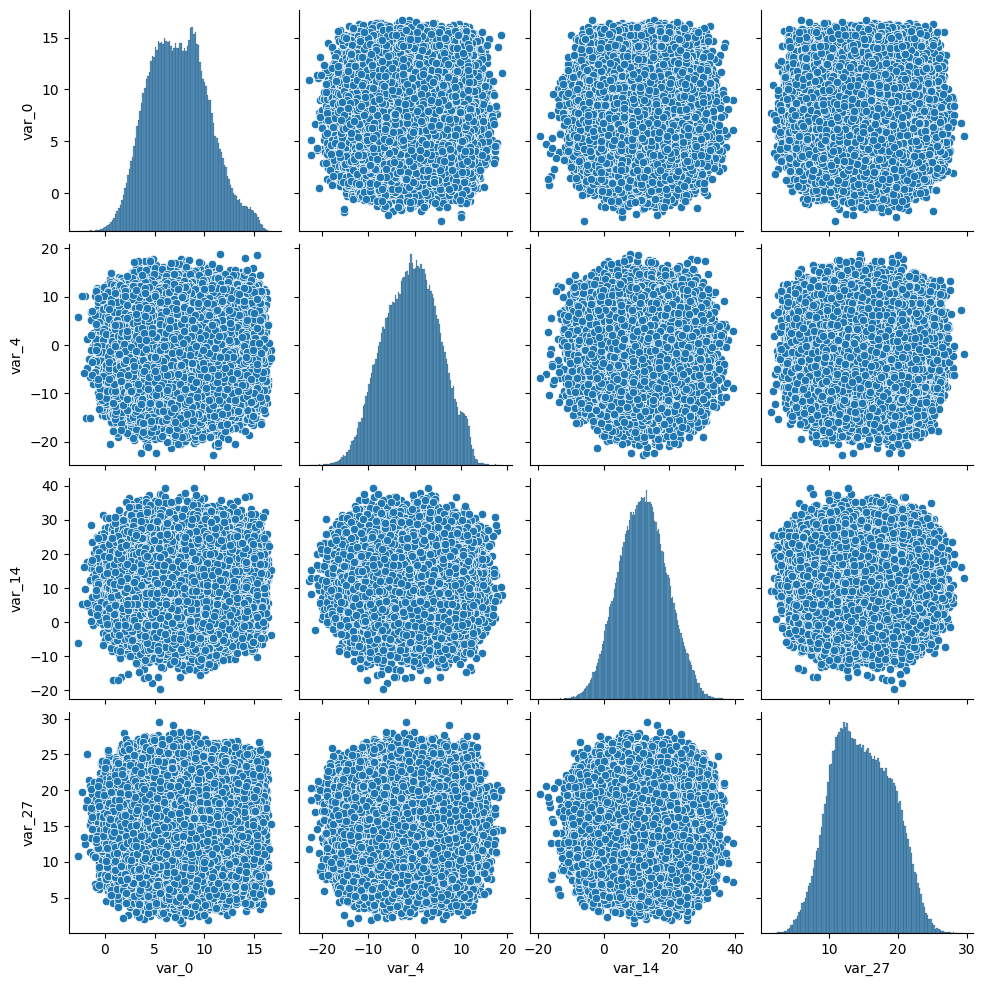

In [109]:
sns.pairplot(txn_train_target,vars=sample_plots)

Text(0.5, 1.0, 'var_0')

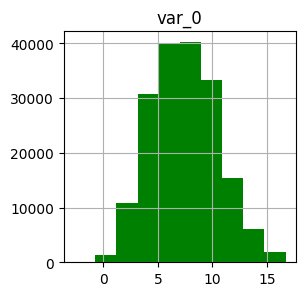

In [110]:
X['var_0'].hist(figsize=(3, 3),color='green')
plt.title('var_0')

Text(0.5, 1.0, 'var_4')

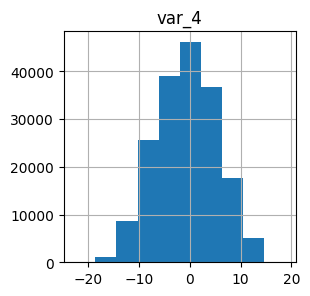

In [111]:
X['var_4'].hist(figsize=(3, 3),color='blue')
plt.title('var_4')

X['var_4'].hist(figsize=(3, 3))
plt.title('var_4')

Text(0.5, 1.0, 'var_14')

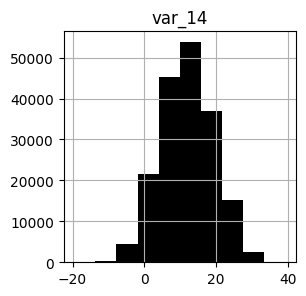

In [112]:
X['var_14'].hist(figsize=(3, 3),color='black')
plt.title('var_14')

Text(0.5, 1.0, 'var_27')

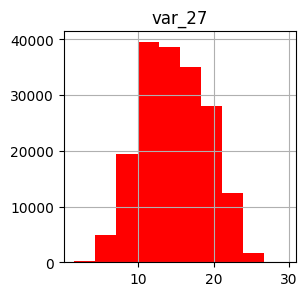

In [113]:
X['var_27'].hist(figsize=(3, 3),color='red')
plt.title('var_27')

###Confusion Matrix

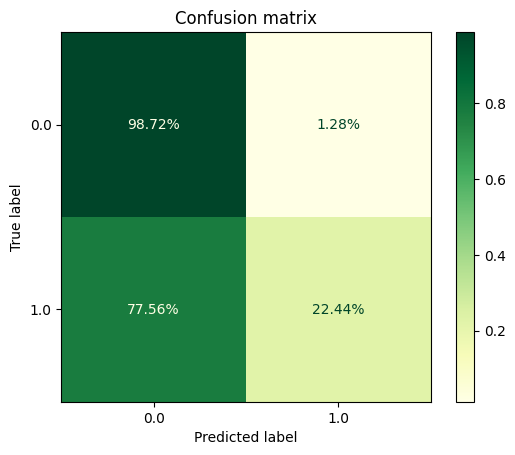

In [114]:
metrics.ConfusionMatrixDisplay.from_estimator(
    gnb,
    X_test,
    y_test,
    normalize = 'true',
    values_format = '.2%',
    cmap = 'YlGn'
    )
plt.grid(False)
plt.title('Confusion matrix');

###Based on this confusion matrix:

The Model predict True Negative high with 98.70% with no transaction and 22.46% of true Positive, i.e., predicting the model correctly.
Hence the dataset is imbalanced.

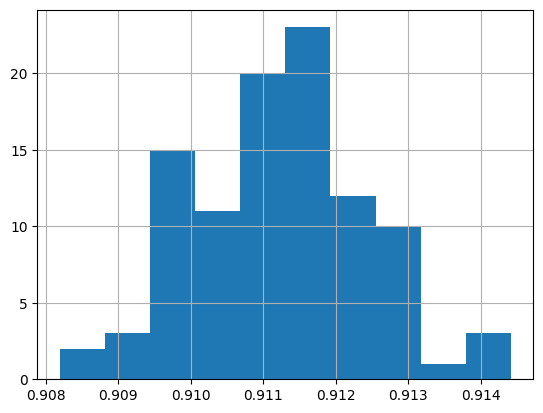

In [115]:
pd.Series(results).hist();